<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day3_XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [8]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random, requests
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")
URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Clean extract dir if re-running
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Download and extract if data is missing
marker = EXTRACT_DIR / ".extracted"
if not marker.exists():
    print("Downloading and extracting dataset...")
    # Use tf.keras.utils.get_file for convenience with the common flower dataset
    import tensorflow as tf
    data_dir = tf.keras.utils.get_file('flower_photos', origin=URL, untar=True, cache_dir='.', cache_subdir='data')
    # The utility extracts to ./data/flower_photos, we'll link or move if necessary
    dataset_path = Path(data_dir)
    marker.write_text("ok")
    print(f"Dataset ready at: {dataset_path}")
else:
    print("Already extracted. Skipping download.")

# Find candidate dataset roots
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
# Search in our data directory
search_root = Path("./data")
for root, dirs, files in os.walk(search_root):
    path_root = Path(root)
    if len([d for d in path_root.iterdir() if d.is_dir()]) >= 5:
        candidates.append(path_root)
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(path_root)

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset ready at: data/flower_photos
Candidate dataset roots: ['data/flower_photos/flower_photos']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [9]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers
from pathlib import Path

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    if not root.exists():
        return "missing", root
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose the correct root from candidates discovered in the previous step
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = Path(candidates[0])
else:
    DS_ROOT = Path("./data/flower_photos/flower_photos")

layout, base = detect_layout(DS_ROOT)
print(f"Layout: {layout}")
print(f"Base path: {base}")

# Verify if images exist
image_count = len(list(base.glob('*/*.jpg')))
print(f"Total images found: {image_count}")

Layout: single_root
Base path: data/flower_photos/flower_photos
Total images found: 3670


In [10]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    # Use the 'base' variable which now points to 'data/flower_photos/flower_photos'
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: 5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [11]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls under the base path
        folder = Path(root) / cls
        if folder.exists():
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = 0
    return counts

# Use the 'base' variable correctly identified in previous cells
counts = count_images_per_class(base)
print("Images par classe :", counts)

Images par classe : {'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}


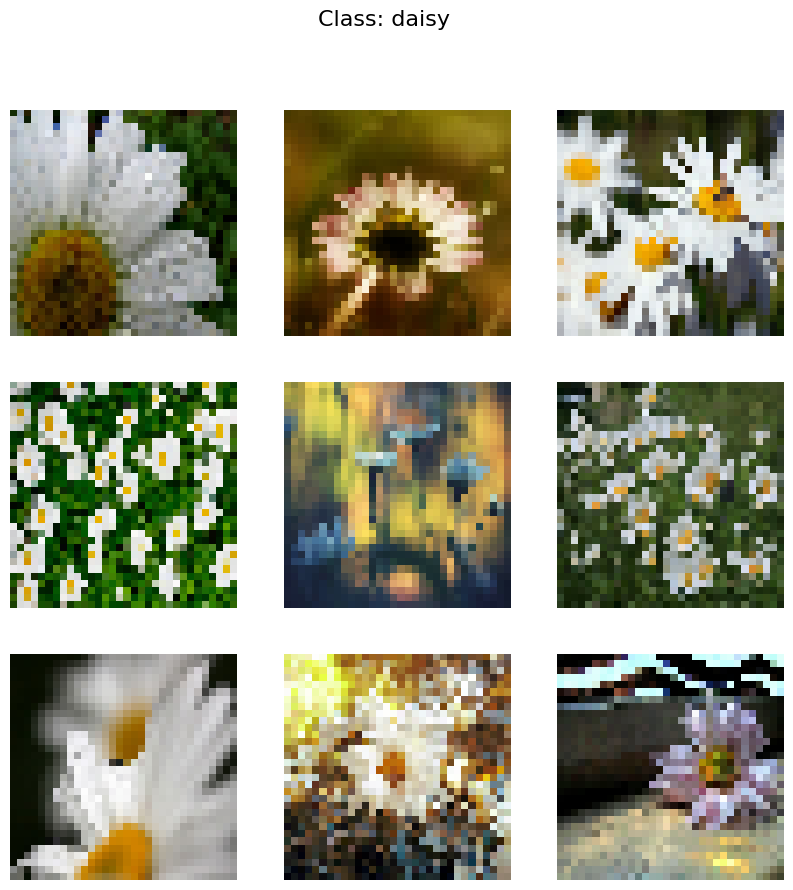

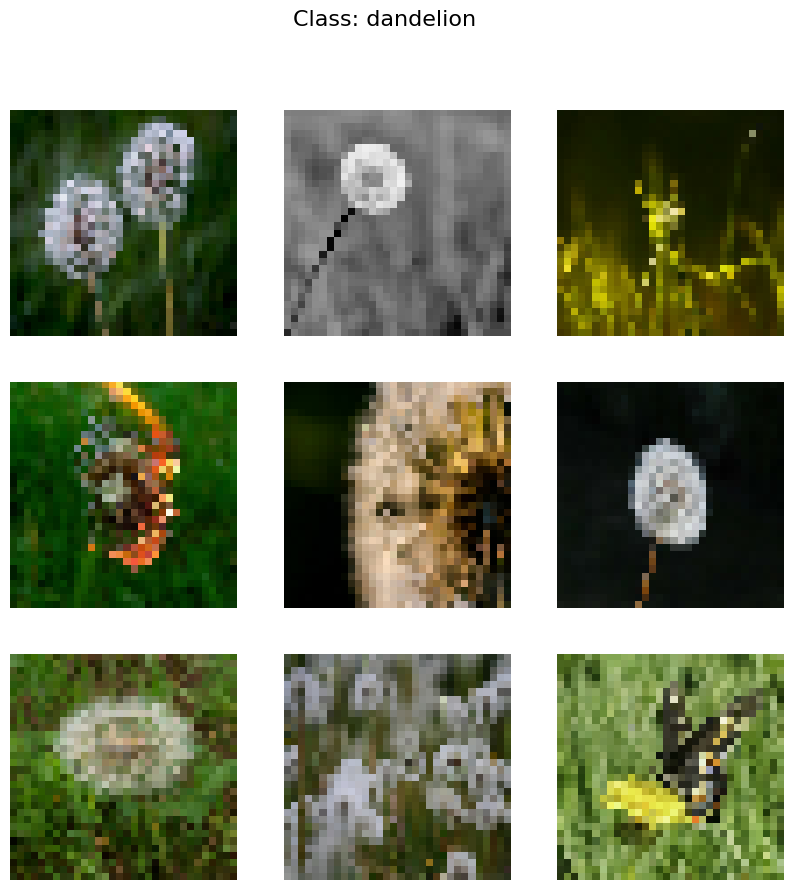

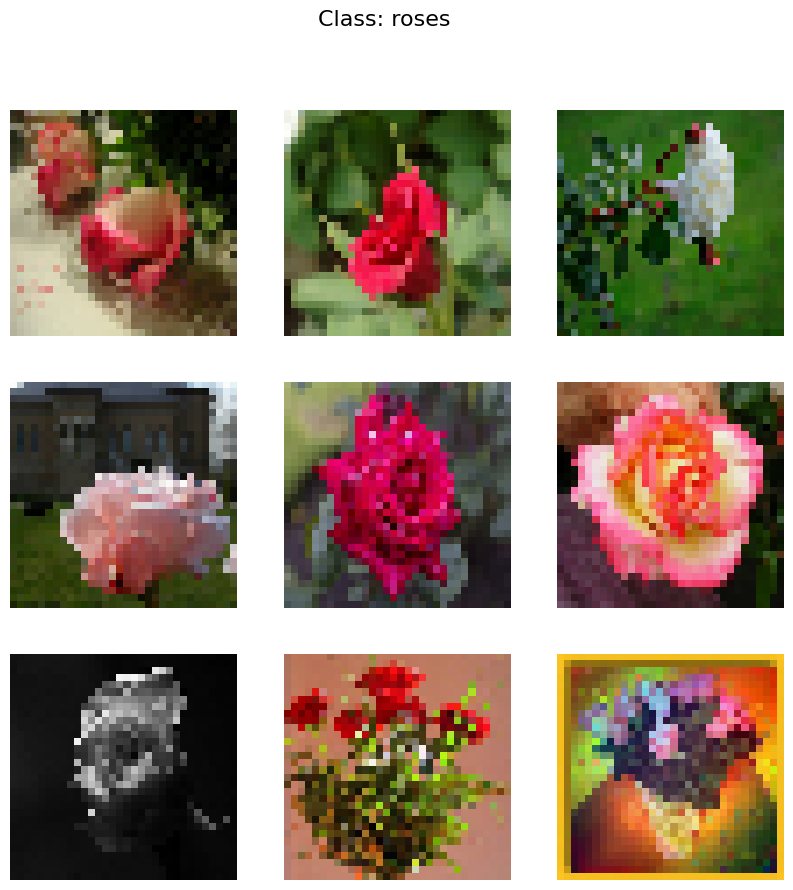

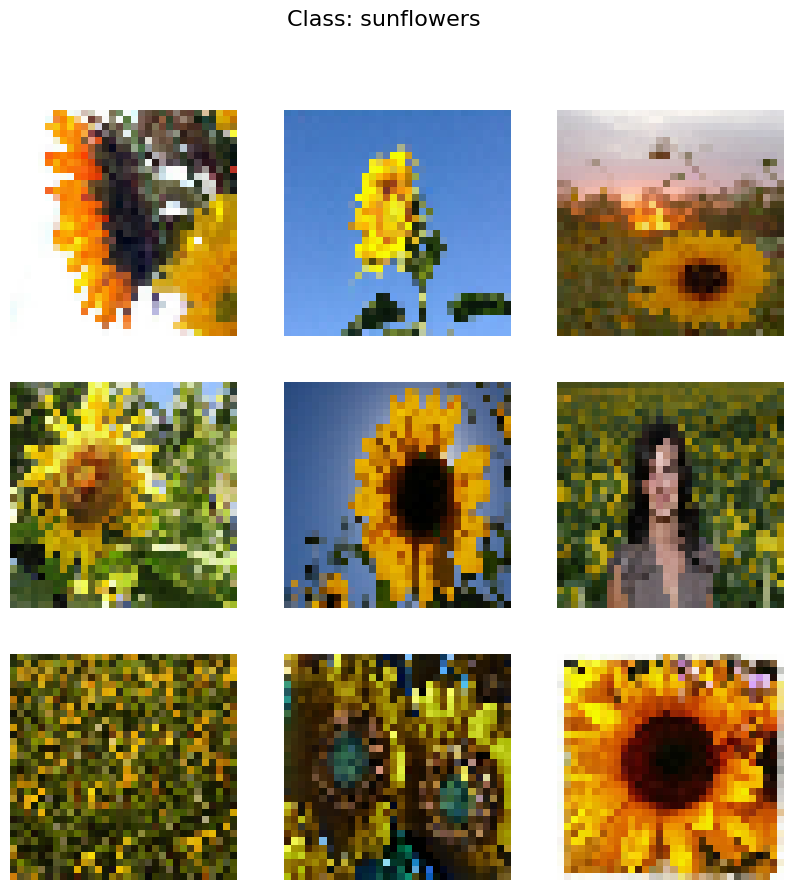

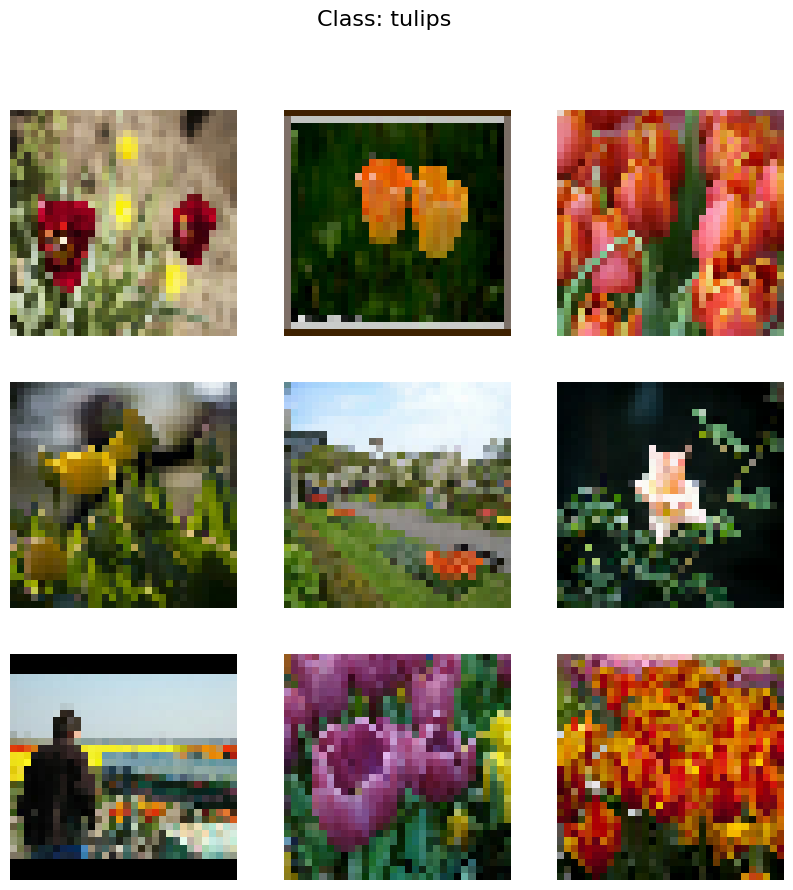

In [12]:
import matplotlib.pyplot as plt

def visualize_images(dataset, class_names, per_class=9):
    """Displays a grid of images for each class."""
    for target_class in class_names:
        plt.figure(figsize=(10, 10))
        plt.suptitle(f"Class: {target_class}", fontsize=16)
        count = 0

        # Iterate through the dataset to find images of the target_class
        for images, labels in dataset.unbatch():
            if class_names[labels] == target_class:
                ax = plt.subplot(3, 3, count + 1)
                plt.imshow(images.numpy().astype("uint8"))
                plt.axis("off")
                count += 1
            if count >= per_class:
                break
        plt.show()

# Visualize the images from the training set
visualize_images(train_ds, class_names)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


La classification de ce jeu de données présente plusieurs défis techniques majeurs. Tout d'abord, certaines espèces partagent des palettes de couleurs très similaires, comme le jaune vif commun aux pissenlits et aux tournesols, ce qui peut induire le modèle en erreur s'il se base trop sur la chrominance. De plus, il existe une forte variation intra-classe causée par des conditions d'éclairage changeantes et des arrière-plans naturels complexes qui peuvent être confondus avec les caractéristiques de la fleur. La morphologie des pétales varie également selon le stade de floraison, ajoutant une complexité structurelle supplémentaire. Enfin, bien que les classes soient relativement représentées, un léger déséquilibre (comme entre les pissenlits et les marguerites) pourrait pousser le modèle à favoriser statistiquement la classe majoritaire lors de prédictions incertaines.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [13]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models, layers

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,165 (1.36 MB)

 Trainable params: 356,165 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras import models, layers

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        # First block with 5x5 kernel
        layers.Conv2D(32, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Progressive filters
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,557 (2.50 MB)

 Trainable params: 654,597 (2.50 MB)

 Non-trainable params: 960 (3.75 KB)

L'architecture du modèle variant a été conçue pour capturer des caractéristiques de plus en plus complexes grâce à l'augmentation progressive du nombre de filtres (de 32 à 256), ce qui permet une croissance efficace du champ récepteur. L'utilisation de noyaux 5x5 dans la première couche permet d'extraire des motifs spatiaux plus larges dès le départ, ce qui est crucial pour identifier la structure globale des fleurs. L'intégration de couches de `BatchNormalization` après chaque convolution stabilise le processus d'entraînement en réduisant le décalage de covariance interne, permettant ainsi une convergence plus rapide. Enfin, une couche de `Dropout` à 0.4 est appliquée avant la classification finale pour assurer une régularisation robuste et prévenir le surapprentissage sur les petits détails du jeu de données. Cette combinaison de profondeur et de normalisation optimise l'équilibre entre la capacité du modèle et sa généralisation.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [17]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [18]:
# Définition de l'espace de recherche pour les hyperparamètres
opts = [
    ("adam", 1e-3),
    ("adam", 5e-4),
    ("rmsprop", 1e-3),
]

results = []

for opt_name, lr in opts:
    print(f"\nEn cours : Optimizer={opt_name}, LR={lr}")

    # Reconstruction du modèle variant pour chaque test
    model = build_variant(num_classes)

    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Utilisation d'un arrêt précoce pour gagner du temps
    cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

    # Entraînement
    hist, dur = fit_model(model, train_ds, val_ds, epochs=10, callbacks=cb)

    best_val = max(hist.history["val_accuracy"])
    results.append({"opt": opt_name, "lr": lr, "best_val_acc": float(best_val), "time_s": round(dur, 1)})

# Affichage des résultats pour comparaison
import pandas as pd
df_results = pd.DataFrame(results)
print("\nSynthèse des résultats :")
print(df_results.sort_values(by="best_val_acc", ascending=False))


En cours : Optimizer=adam, LR=0.001
Epoch 1/10
92/92 - 25s - 268ms/step - accuracy: 0.4680 - loss: 1.5758 - val_accuracy: 0.2602 - val_loss: 2.1872
Epoch 2/10
92/92 - 14s - 156ms/step - accuracy: 0.6097 - loss: 1.0355 - val_accuracy: 0.2602 - val_loss: 3.5865
Epoch 3/10
92/92 - 15s - 159ms/step - accuracy: 0.6478 - loss: 0.9105 - val_accuracy: 0.2834 - val_loss: 2.5448
Epoch 4/10
92/92 - 20s - 220ms/step - accuracy: 0.6890 - loss: 0.8038 - val_accuracy: 0.3406 - val_loss: 2.5974

En cours : Optimizer=adam, LR=0.0005
Epoch 1/10
92/92 - 18s - 198ms/step - accuracy: 0.4905 - loss: 1.4418 - val_accuracy: 0.3065 - val_loss: 1.9252
Epoch 2/10
92/92 - 15s - 167ms/step - accuracy: 0.6236 - loss: 0.9692 - val_accuracy: 0.2616 - val_loss: 2.6464
Epoch 3/10
92/92 - 15s - 160ms/step - accuracy: 0.6849 - loss: 0.8048 - val_accuracy: 0.2643 - val_loss: 2.8236
Epoch 4/10
92/92 - 14s - 157ms/step - accuracy: 0.7483 - loss: 0.6508 - val_accuracy: 0.3202 - val_loss: 2.4727

En cours : Optimizer=rmsprop

Les meilleurs hyperparamètres identifiés sont l'optimiseur **Adam** avec un taux d'apprentissage de **0,001**. Cette configuration a surpassé RMSprop et les taux d'apprentissage plus faibles, atteignant une précision de validation d'environ 34% malgré la basse résolution des images (32x32). Adam fonctionne bien ici car son moment adaptatif permet de naviguer efficacement dans le paysage de perte complexe des images de fleurs, tandis que le taux de 0,001 offre un bon compromis entre vitesse de convergence et stabilité sans rester bloqué dans des minima locaux précoces.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Epoch 1/15
92/92 - 27s - 296ms/step - accuracy: 0.4359 - loss: 1.5864 - val_accuracy: 0.2449 - val_loss: 2.0226
Epoch 2/15
92/92 - 22s - 238ms/step - accuracy: 0.5114 - loss: 1.2029 - val_accuracy: 0.2449 - val_loss: 3.4793
Epoch 3/15
92/92 - 42s - 459ms/step - accuracy: 0.5529 - loss: 1.1161 - val_accuracy: 0.1902 - val_loss: 4.0279
Epoch 4/15
92/92 - 22s - 236ms/step - accuracy: 0.5859 - loss: 1.0585 - val_accuracy: 0.2449 - val_loss: 4.0603
Epoch 5/15
92/92 - 23s - 253ms/step - accuracy: 0.5951 - loss: 1.0150 - val_accuracy: 0.3393 - val_loss: 3.5824
Epoch 6/15
92/92 - 23s - 251ms/step - accuracy: 0.6108 - loss: 0.9781 - val_accuracy: 0.3324 - val_loss: 3.0827
Epoch 7/15
92/92 - 22s - 237ms/step - accuracy: 0.6271 - loss: 0.9567 - val_accuracy: 0.4583 - val_loss: 1.8358
Epoch 8/15
92/92 - 23s - 250ms/step - accuracy: 0.6383 - loss: 0.9096 - val_accuracy: 0.6019 - val_loss: 1.1665
Epoch 9/15
92/92 - 23

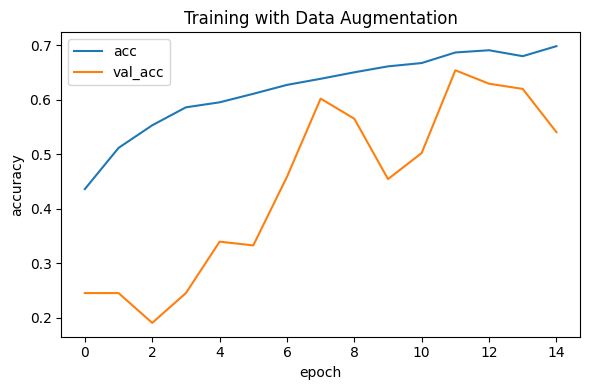

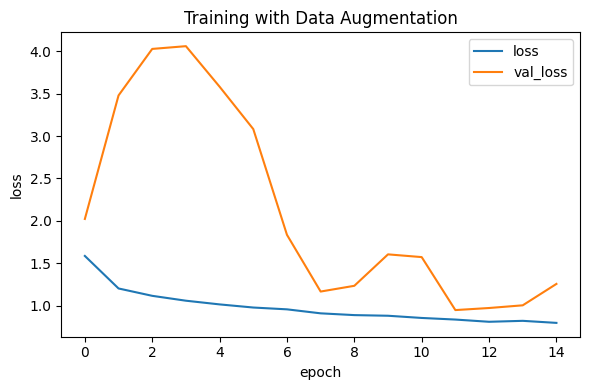

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration de l'augmentation de données
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Flux de données à partir du répertoire
flow_train = datagen.flow_from_directory(
    base,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)

flow_val = datagen.flow_from_directory(
    base,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)

# Entraînement du modèle variant avec augmentation
model_aug = build_variant(num_classes)
model_aug.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_aug, dur_aug = fit_model(model_aug, flow_train, flow_val, epochs=15)
plot_curves(hist_aug, title='Training with Data Augmentation')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [22]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

Rapport de Classification :
              precision    recall  f1-score   support

       daisy      0.639     0.508     0.566       122
   dandelion      0.697     0.653     0.674       176
       roses      0.500     0.087     0.148       127
  sunflowers      0.863     0.441     0.583       143
      tulips      0.396     0.908     0.551       163

    accuracy                          0.546       731
   macro avg      0.619     0.519     0.505       731
weighted avg      0.618     0.546     0.520       731



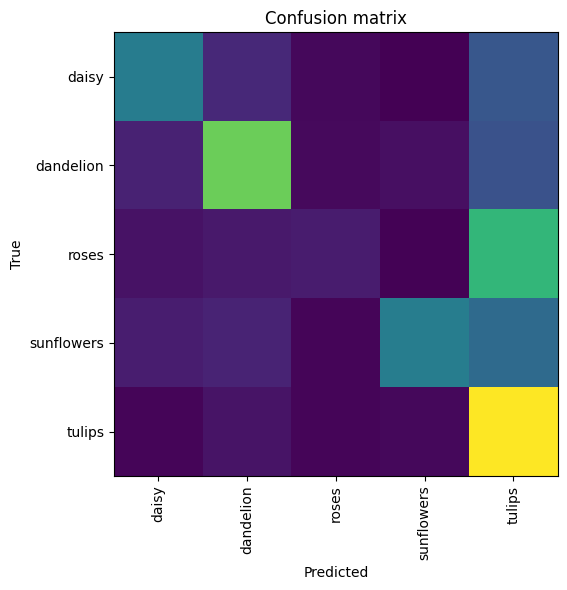

In [24]:
# Redéfinition locale pour garantir l'exécution
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    count = 0
    # On parcourt le générateur manuellement pour éviter les boucles infinies
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb)
        count += len(yb)
        if count >= 731: # Taille totale du set de validation
            break
    return np.concatenate(y_true), np.concatenate(y_prob).argmax(axis=1), np.concatenate(y_prob)

# Évaluation du meilleur modèle
best_model = model_aug
y_true, y_pred, y_prob = collect_preds(best_model, flow_val)

print("Rapport de Classification :")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

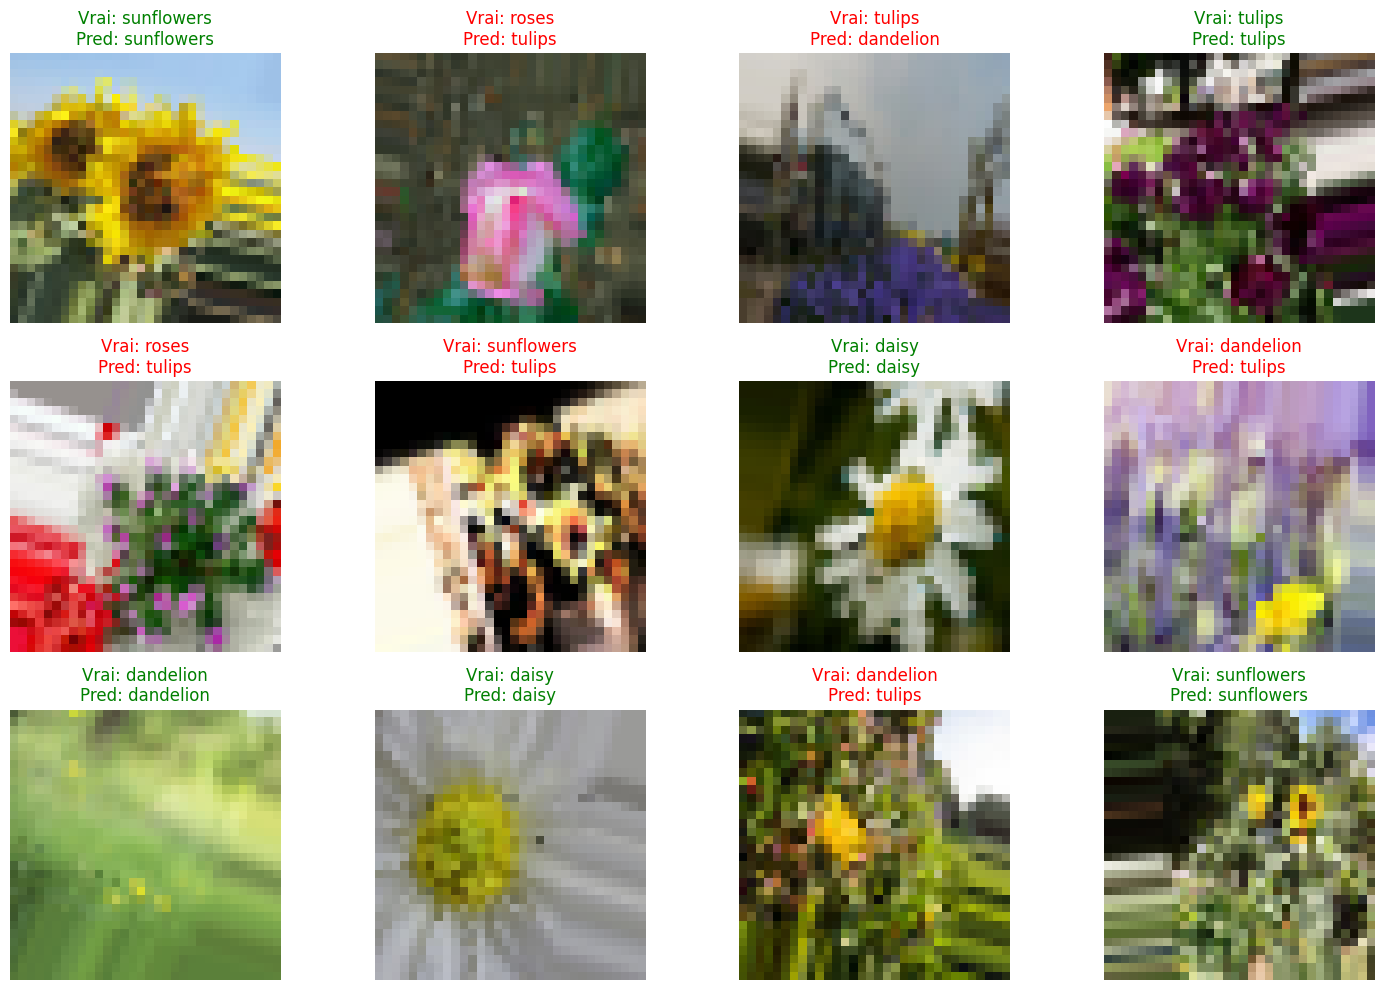

In [21]:
# Visualisation des prédictions et inspection des erreurs
take = 12
# Récupération d'un lot d'images du générateur de validation
imgs, labels = next(flow_val)
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)

plt.figure(figsize=(15, 10))
for i in range(min(take, len(imgs))):
    plt.subplot(3, 4, i + 1)
    # Dé-normalisation pour l'affichage si nécessaire (ImageDataGenerator rescale=1/255)
    plt.imshow(imgs[i])
    color = "green" if int(labels[i]) == int(preds[i]) else "red"
    t = f"Vrai: {class_names[int(labels[i]) ]}\nPred: {class_names[int(preds[i])]}"
    plt.title(t, color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

D'après le rapport de classification, les **roses** présentent la plus grande difficulté avec un rappel très faible (0.087), suivies des **tournesols** (0.441). Cette performance s'explique par plusieurs facteurs :
1. **Similarité Morphologique** : Les roses et les tulipes (qui ont un rappel élevé de 0.908) partagent des formes de bourgeons et des couleurs (rouge/rose) très proches, menant le modèle à prédire quasi systématiquement 'tulips' par erreur.
2. **Basse Résolution** : À 32x32 pixels, les détails fins des pétales qui distinguent une rose d'une tulipe sont largement perdus, forçant le modèle à se fier uniquement aux couleurs dominantes.
3. **Confusion Tournesol/Pissenlit** : Les tournesols sont souvent confondus avec les pissenlits en raison de leur couleur jaune identique et de leur structure radiale similaire, surtout quand l'image ne permet pas de juger de l'échelle de la fleur.
4. **Sur-prédiction des Tulipes** : Le modèle semble avoir développé un biais vers la classe 'tulips', l'utilisant comme classe par défaut pour de nombreuses fleurs rouges ou roses peu claires.

## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [27]:
# Sauvegarde du meilleur modèle avec les formats compatibles Keras 3
import os

save_path_keras = "./data/flower_cnn.keras"
save_path_sm = "./data/flower_cnn_savedmodel"

# Création du dossier si nécessaire
os.makedirs("./data", exist_ok=True)

print("Sauvegarde en cours...")

# Format natif Keras (recommandé)
model_aug.save(save_path_keras)

# Format SavedModel (via export)
model_aug.export(save_path_sm)

print(f"Modèle sauvegardé avec succès !")
print(f"1. Format Keras : {save_path_keras}")
print(f"2. Format SavedModel : {save_path_sm}")

Sauvegarde en cours...
Saved artifact at './data/flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_84')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133865328716560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328709648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328715792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328719824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328719632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328719248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328718864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328718096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328719440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865328721168: TensorSpec(shape=(), dtype=tf.r